## Домашнее задание №1 "Модель движения и формирование потока измерений"

Для выполнения домашнего задания потребуется python3 с установленными библиотеками numpy, scipy, json, plotly.

Изучите пример и выполните задание по вариантам.

### Варианты
|    | Pd  | Pfa  | dR(м) | dT(гр) | To(с) | $(x_{рлс},y_{рлс})$(м) | $t_1$(с) | V(м/с) | w(гр/с) | a(гр) | $t_2$(с) | $(x_{ц},y_{ц}) $ |
|----|-----|------|-------|--------|-------|------------------------|----------|--------|---------|-------|----------|------------------|
| 15 | 0.5 | 1e-4 | 150   | 5      | 6     | (100,1200)             | 30       | 50     | 2       | -135  | 20       | (-5000,-5000)    |

>Сформируйте поток измерений от одиночной цели с выхода обзорной РЛС, о которой известно, что Pd = 0,9, Pfa = 1e-5, разрешающая способность по дальности 15м, ширина ДН в азимутальной плоскости 1гр, период обзора 3с, дальность действия РЛС 10км.
>
>Цель должна появляться на 50 секунде наблюдения в точке (5000, 5000), двигаться с примерно постоянной полной скоростью 20м/с по направлению к РЛС в течение 50 секунд, после чего она должна совершить разворот с угловой скоростью 2гр/с и вернуться в исходное положение с той же скоростью. Случайные отклонения по ускорению цели не должны превышать 0,5 м/с/с.
>
>Измерения должны быть получены в полярной системе координат.

### Пример решения

Загрузим библиотеки, которые могут потребоваться при решении задачи.

In [5]:
import json                 # библиотека работы с json файлами
import matplotlib.pyplot as plt # библиотека функций графиков
import numpy as np          # библиотека математических функций
from scipy.stats import norm, uniform  # загрузка статистических функций

seed_target = 2026
seed_measurements = 4

ModuleNotFoundError: No module named 'matplotlib'

Создадим сложный тип данных (класс), описывающий движение объекта 

In [6]:
class Target():
    """
    target model description
    """
    def __init__(self, seed):
        self.targetState = {                                   # state vector
            'x':0.0,'vx':0.0,'ax':0.0, # x states
            'y':0.0,'vy':0.0,'ay':0.0, # y states
            'w':0.0} # angular velocity
        self.processNoise = {'ax':0.0, 'ay':0.0, 'nw':0.0}    # process noise vector
        self.rand_gen = np.random.default_rng(seed)           # set seed for random numbers
        
    def init_state(self,state):
        initKeys = state.keys()                               # init targetState components
        for k in initKeys:
            self.targetState[k] = state[k]                    # set values with same keys
    
    def init_process_noise(self,pn):
        initKeys = pn.keys()                                 # init processNoise components
        for k in initKeys:
            self.processNoise[k] = pn[k]                     # set values with same keys
    
    def CV(self, dt = 1.0):
        # move target with CV model due dt
        keys = ['x','vx','y','vy']
        X = np.array([self.targetState[i] for i in keys])
        F = np.array(
            [[1.0,  dt,     0.0,    0.0],
             [0.0,  1.0,    0.0,    0.0],
             [0.0,  0.0,    1.0,    dt],
             [0.0,  0.0,    0.0,    1.0]])
        
        G = np.array(
            [[dt**2/2,  0.0],
             [dt,       0.0],
             [0.0,      dt**2/2],
             [0.0,      dt]])
        
        w = self.rand_gen.normal([0.0,0.0],[self.processNoise['ax'],self.processNoise['ay']])
        Xe = F@X+G@w

        for (i,k) in enumerate(keys):
            self.targetState[k] = Xe[i]
        return {k:self.targetState[k] for k in self.targetState.keys()} # return new dictionary
    
    def CA(self, dt = 1.0):
        # move target with CV model due dt
        keys = ['x','vx','ax','y','vy','ay']
        X = np.array([self.targetState[i] for i in keys])
        F = np.array(
            [[1.0,  dt,     dt**2/2,    0.0,    0.0,    0.0],
             [0.0,  1.0,    dt,         0.0,    0.0,    0.0],
             [0.0,  0.0,    1.0,        0.0,    0.0,    0.0],
             [0.0,  0.0,    0.0,        1.0,    dt,     dt**2/2],
             [0.0,  0.0,    0.0,        0.0,    1.0,    dt],
             [0.0,  0.0,    0.0,        0.0,    0.0,    1]
             ])
        
        G = np.array(
            [[dt**2/2,  0.0],
             [dt,       0.0],
             [1.0,      0.0],
             [0.0,      dt**2/2],
             [0.0,      dt],
             [0.0,      1.0]
             ])
        
        w = self.rand_gen.normal([0.0,0.0],[self.processNoise['ax'],self.processNoise['ay']])
        Xe = F@X+G@w

        for (i,k) in enumerate(keys):
            self.targetState[k] = Xe[i]
        return {k:self.targetState[k] for k in self.targetState.keys()} # return new dictionary
        
    def CT(self, dt = 1.0):
        # move target with CT model due dt
        keys = ['x','y','vx','vy','w']
        X = np.array([self.targetState[i] for i in keys])
        w = self.targetState['w'] # save w value
        
        F = np.array(
            [[1.0,  0.0,    1/w*np.sin(w*dt),    -1/w*(1-np.cos(w*dt)), 0.0],
             [0.0,  1.0,    1/w*(1-np.cos(w*dt)), 1/w*np.sin(w*dt),     0.0],
             [0.0,  0.0,    np.cos(w*dt),        -np.sin(w*dt),         0.0],
             [0.0,  0.0,    np.sin(w*dt),        np.cos(w*dt),          0.0],
             [0.0,  0.0,    0.0,                 0.0,                   1.0]])
        
        G = np.array(
            [[dt**2/2,  0.0,     0.0],
             [0.0,      dt**2/2, 0.0],
             [dt,       0.0,     0.0],
             [0.0,      dt,      0.0],
             [0.0,      0.0,     1.0]])
        
        n = self.rand_gen.normal([0.0,0.0,0.0], [self.processNoise['ax'],self.processNoise['ay'],self.processNoise['nw']])
        Xe = F@X+G@n
        
        for (i,k) in enumerate(keys):
            self.targetState[k] = Xe[i]
        return {k:self.targetState[k] for k in self.targetState.keys()} # return new dictionary


Создадим массивы для хранения результатов и сформируем участки траекторий. Т.к. период следования отсчетов не кратен периодам наблюдения, то на границах участков движения скорректируем начальный вектор состояния до следующего периода вторичной обработки.

In [ ]:
x = []  # массив координат x цели
y = []  # массив координат y цели

deg = np.pi/180     # пересчет градусы в радианы
rad = 180/np.pi     # пересчет радианы в градусы

# создаем объект цель и задаем его параметры
tg = Target(seed_target)        
tg.init_state({'x':5000.0,'y':5000.0,'vx':14.0,'vy':14.0,'w':2*deg})
tg.init_process_noise({'ax':0.5/3,'ay':0.5/3, 'nw':0.01*deg/3})

To = 3.0    # такт вторичной обработки    
# участок №1
init = 1                            # признак начала участка траектории
for time in range(0,100,int(To)):
    if (time < 50):
        x.append(np.nan)
        y.append(np.nan)
    else:
        if (init == 1):
            state = tg.CV(dt = time % To) # 51 секунда наблюдения
            init = 0
        else:
            state = tg.CV(dt = To)
        x.append(state['x'])
        y.append(state['y'])
state = tg.CV(dt = time % To)       # 100 секунда наблюдения

# участок №2
w = 2*deg                           # угловая скорость поворота по чс
angles = np.arange(0,180*deg, w*To) # угловые положения на каждый такт вторичной обработки
for th in angles:
    state = tg.CT(dt = To)
    x.append(state['x'])
    y.append(state['y'])
state = tg.CV(dt = 180*deg % w)     # доворот на 180 градусов перед началом следующего участка
    

# участок №3
for i in range(int(50/To)):                 # генерация ещё 50 отсчетов движения цели
    state = tg.CV(dt = To)
    x.append(state['x'])
    y.append(state['y'])

with open('track.json','w', encoding='utf-8') as f:
    json.dump({'tg1':{'dt':To,'x':x,'y':y}}, f, ensure_ascii=False, indent=4)

Отобразим полученную траекторию

(0.0, 10000.0)

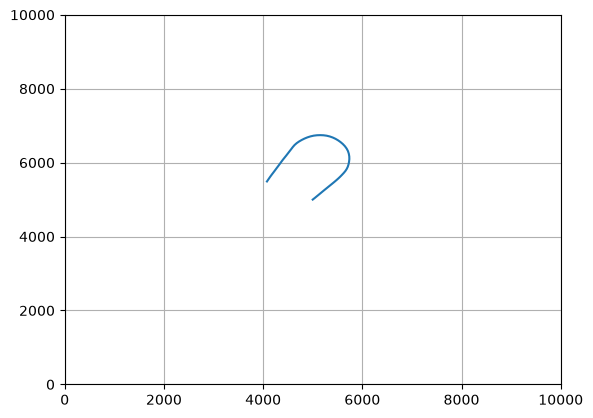

In [ ]:
plt.plot(x,y)
plt.grid()
plt.xlim([0,10000])
plt.ylim([0,10000])

In [ ]:
Pd = 0.9        # вероятность правильного обнаружения цели
dt = 3.0        # период обзора пространства
sr = 15/2       # ско измерения по дальности
sa = 1/2*deg    # ско измерения по углу

pos_x = 0
pos_y = 0

n = len(x)                              # число точек в траектории
t = np.arange(0.0,n*dt,dt)              # шкала времени прихода измерений
mr = np.sqrt((np.array(x)-pos_x)**2+(np.array(y)-pos_y)**2) + norm.rvs(scale=sr, size=n, random_state=seed_measurements)    # результаты измерений по дальности
ma = np.arctan2((np.array(y)-pos_y),(np.array(x)-pos_x)) + norm.rvs(scale=sa, size=n, random_state=seed_measurements)       # результаты измерений по углу

# формирование фомруляров измерений для всех тактов траекторной обработки
measurements = []
for i in range(n):
    if uniform.rvs() < Pd:
        measurements.append({'r':mr[i],'phi':ma[i],'t':t[i]})
    else:
        mr[i] = np.nan  # исключение измерений из выборки 
        ma[i] = np.nan
        
with open('track_measurements_polar.json','w', encoding='utf-8') as writefile:
    json.dump(measurements, writefile, ensure_ascii=False, indent=4)

Отобразим измерения и траекторию на одном графике

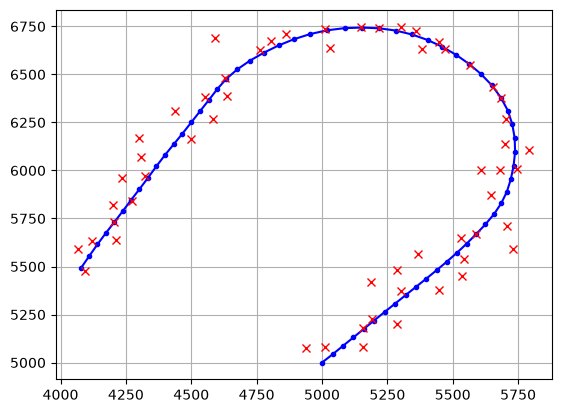

In [ ]:
plt.plot(x,y, 'b.') # отображение истинного положения цели в виде синих точек
plt.plot(x,y, 'b-') # отображение истинного положения цели в виде синий непрерывной прямой
plt.plot(mr*np.cos(ma)+pos_x,mr*np.sin(ma)+pos_y, 'rx') # отображение измерений в виде красных крестиков
plt.grid() # отображение вспопогательных линий на графике

## Задание

Сформируйте поток измерений от одиночной цели с выхода обзорной РЛС, о которой известно, что **Pd**, **Pfa**, разрешающая способность по дальности **dR(м)**, ширина ДН в азимутальной плоскости **dT(гр)**, период обзора **To (с)**, дальность действия РЛС **10 (км)**. Координаты РЛС $(x_{рлс}, y_{рлс})$ (м).

Цель должна появляться на $t_1$ секунде наблюдения в точке $(x_{ц}, y_{ц})$, двигаться с примерно постоянной полной скоростью **V** (м/с) по направлению к РЛС в течение 50 секунд, после чего она должна совершить поворот с угловой скоростью **w** (гр/с) на **a** (гр) и продолжить движение ещё $t_2$ секунд . Случайные отклонения по ускорению цели не должны превышать **0,5 (м/с/с)**.

Измерения должны быть получены в полярной системе координат.

### Варианты
|    | Pd  | Pfa  | dR(м) | dT(гр) | To(с) | $(x_{рлс},y_{рлс})$(м) | $t_1$(с) | V(м/с) | w(гр/с) | a(гр) | $t_2$(с) | $(x_{ц},y_{ц}) $ |
|----|-----|------|-------|--------|-------|------------------------|----------|--------|---------|-------|----------|------------------|
| 1  | 0.9 | 1e-4 | 15    | 1      | 1     | (1000,100)             | 10       | 50     | 2       | 45    | 40       | (5000,5000)      |
| 2  | 0.8 | 1e-5 | 7.5   | 2      | 3     | (100,1000)             | 20       | 25     | 3       | 90    | 30       | (-5000,5000)     |
| 3  | 0.7 | 1e-6 | 30    | 5      | 6     | (-1500,1500)           | 30       | 10     | 5       | 135   | 20       | (5000,-5000)     |
| 4  | 0.6 | 1e-4 | 60    | 1      | 12    | (1000,1000)            | 40       | 75     | 10      | 180   | 100      | (-5000,-5000)    |
| 5  | 0.5 | 1e-5 | 150   | 2      | 1     | (1000,-1500)           | 10       | 50     | 2       | -45   | 40       | (5000,5000)      |
| 6  | 0.9 | 1e-6 | 15    | 5      | 3     | (1500,1000)            | 20       | 25     | 3       | -90   | 30       | (-5000,5000)     |
| 7  | 0.8 | 1e-4 | 7.5   | 1      | 6     | (-1200,100)            | 30       | 10     | 5       | -135  | 20       | (5000,-5000)     |
| 8  | 0.7 | 1e-5 | 3.75  | 2      | 12    | (100,1200)             | 40       | 75     | 10      | -180  | 100      | (-5000,-5000)    |
| 9  | 0.6 | 1e-6 | 1     | 5      | 1     | (100,-100)             | 10       | 25     | 10      | -270  | 40       | (5000,5000)      |
| 10 | 0.5 | 1e-7 | 100   | 1      | 3     | (-100,-100)            | 20       | 10     | 10      | 270   | 30       | (-5000,-5000)    |
| 11 | 0.9 | 1e-4 | 15    | 2      | 6     | (1000,-1500)           | 30       | 50     | 2       | 135   | 20       | (-5000,-5000)    |
| 12 | 0.8 | 1e-5 | 7.5   | 5      | 12    | (1500,1000)            | 40       | 25     | 3       | 180   | 100      | (5000,5000)      |
| 13 | 0.7 | 1e-6 | 30    | 1      | 1     | (100,1000)             | 10       | 10     | 5       | -45   | 40       | (-5000,5000)     |
| 14 | 0.6 | 1e-7 | 60    | 2      | 3     | (-1200,100)            | 20       | 75     | 10      | -90   | 30       | (5000,-5000)     |
| 15 | 0.5 | 1e-4 | 150   | 5      | 6     | (100,1200)             | 30       | 50     | 2       | -135  | 20       | (-5000,-5000)    |

Работа должна быть выполнена в новом jupyter notebook, без копирования примера решения задачи. Файл должен быть в формате **"group-var-lastname".ipynb**

Результаты прислать на электронную почту.